In [ ]:
!pip install tensorflow pandas numpy matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_users = 20
days_per_user = 50

rows = []

for user in range(1, num_users + 1):
    dates = pd.date_range("2026-01-01", periods=days_per_user)
    mood = np.random.uniform(0.5, 0.9)

    for date in dates:
        mood += np.random.normal(0, 0.03)
        mood = np.clip(mood, 0.1, 1.0)

        rows.append([
            date.strftime("%Y-%m-%d"),
            user,
            round(mood, 2)
        ])

df = pd.DataFrame(rows, columns=["Date", "User_ID", "MoodScore"])

df.to_csv("daily_mood.csv", index=False)

print("CSV created successfully!")

CSV created successfully!


In [6]:
data = pd.read_csv("daily_mood.csv")

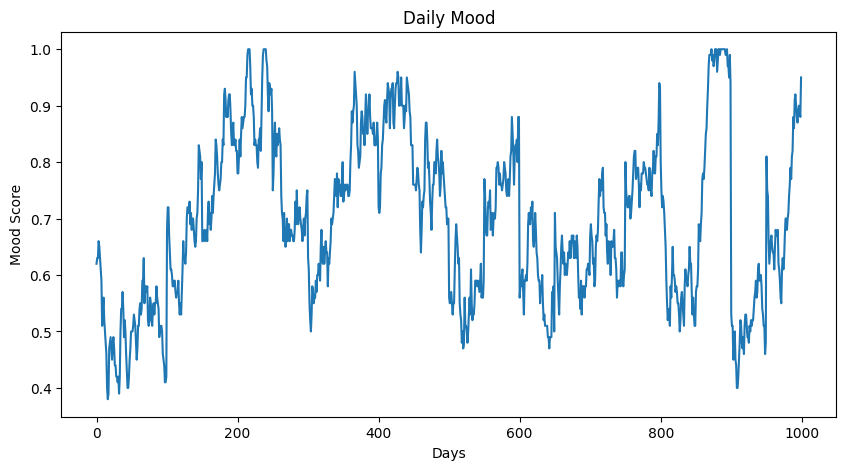

In [7]:
plt.figure(figsize=(10,5))

plt.plot(data["MoodScore"])

plt.title("Daily Mood")

plt.xlabel("Days")

plt.ylabel("Mood Score")

plt.show()

In [8]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data[["MoodScore"]])

In [9]:
sequence_length = 7

In [10]:
def create_sequences(data, seq_len):

    X=[]

    y=[]

    for i in range(len(data)-seq_len):

        X.append(data[i:i+seq_len])

        y.append(data[i+seq_len])

    return np.array(X), np.array(y)

In [11]:
X,y=create_sequences(scaled,7)

In [12]:
split=int(len(X)*0.8)

X_train=X[:split]

X_test=X[split:]

y_train=y[:split]

y_test=y[split:]

In [ ]:
model=Sequential()

model.add(LSTM(64,return_sequences=True,input_shape=(7,1)))

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(1))

In [14]:
model.compile(

optimizer="adam",

loss="mse",

metrics=["mae"]
)

In [15]:
history=model.fit(

X_train,

y_train,

epochs=30,

batch_size=8,

validation_split=0.2
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0426 - mae: 0.1453 - val_loss: 0.0068 - val_mae: 0.0645
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0150 - mae: 0.0964 - val_loss: 0.0073 - val_mae: 0.0657
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0152 - mae: 0.0955 - val_loss: 0.0062 - val_mae: 0.0610
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0141 - mae: 0.0903 - val_loss: 0.0060 - val_mae: 0.0599
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0135 - mae: 0.0907 - val_loss: 0.0061 - val_mae: 0.0596
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - mae: 0.0831 - val_loss: 0.0058 - val_mae: 0.0583
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0137 - mae: 0.0896 - val_loss: 0.0058 - val_mae: 0.0577
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0114 - mae: 0.0815 - val_loss: 0.0060 - val_mae: 0.0589
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0110 - mae:

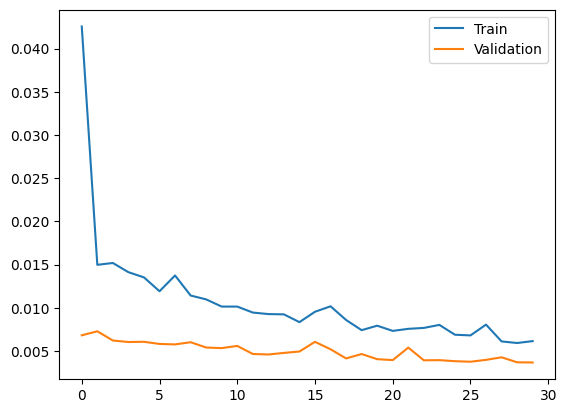

In [16]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

In [17]:
pred=model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [18]:
pred=scaler.inverse_transform(pred)

actual=scaler.inverse_transform(y_test)

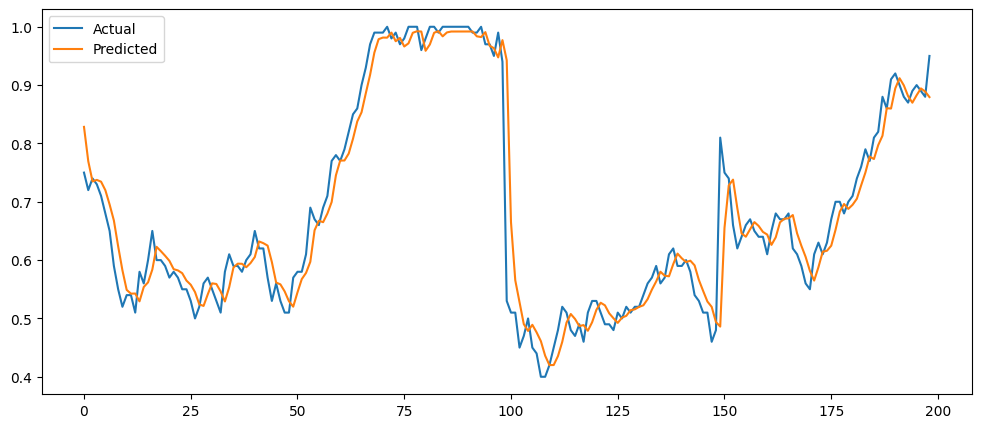

In [19]:
plt.figure(figsize=(12,5))

plt.plot(actual)

plt.plot(pred)

plt.legend(["Actual","Predicted"])

plt.show()

In [20]:
model.save("lstm_model.keras")

In [21]:
from google.colab import files

files.download("lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>